In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [87]:
df=pd.read_csv('C:/Users/aparn/Downloads/abc_company_dataset.csv')
df    #load dataset

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,06-Mar,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,06-Jan,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,07-Mar,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0


In [88]:
# Replace height column with random values between 150 and 180
np.random.seed(42) 
df['Height']=np.random.randint(150,181, size=len(df))
df


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,156,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,169,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,164,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,160,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,168,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,153,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,152,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,166,231,Kansas,947276.0


In [89]:
df.isnull().sum()

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [90]:
df['Salary'].fillna(df['Salary'].median(), inplace=True)
df['College'].fillna('Unknown', inplace=True)
df.isnull().sum()

C:\Users\aparn\AppData\Local\Temp\ipykernel_15496\3249699757.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(df['Salary'].median(), inplace=True)
C:\Users\aparn\AppData\Local\Temp\ipykernel_15496\3249699757.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


Name        0
Team        0
Number      0
Position    0
Age         0
Height      0
Weight      0
College     0
Salary      0
dtype: int64

# Analysis

In [92]:
team_dist = df['Team'].value_counts() #team distribution and percentage split
team_percen = (team_dist/len(df))*100
team_percen

Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
New York Knicks           3.493450
Milwaukee Bucks           3.493450
Brooklyn Nets             3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thunder     3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Miami Heat                3.275109
Charlotte Hornets         3.275109
Atlanta Hawks             3.275109
San Antonio Spurs         3.275109
Houston Rockets           3.275109
Boston Celtics            3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Sacramento Kings          3.275109
Phoenix Suns              3.275109
Los Angeles Lakers        3.275109
Los Angeles Clippers      3.275109
Golden State Warriors     3.275109
Toronto Raptors           3.275109
Philadelphia 76ers        3.275109
Dallas Mavericks          3.275109
Orlando Magic  

In [93]:
# position segregation of employees
position_segg=df['Position'].value_counts()
position_segg

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64

In [94]:
# findning predominant age group
ages=[20,25,30,35,40,45]
age_labels=['21-25','26-30','31-35','36-40','41-45']
df['Age_Group']=pd.cut(df['Age'], bins=ages, labels=age_labels, right=False)
predominat_age_group=df['Age_Group'].value_counts().idxmax()
df
predominat_age_group


'26-30'

In [95]:
#  Team & Position with Highest Salary Expenditure
team_salary=df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
top_salary_team=team_salary.idxmax()
top_salary_team

'Cleveland Cavaliers'

In [96]:
position_salary=df.groupby('Position')['Salary'].sum().sort_values(ascending=False)
position_highest_salary=position_salary.idxmax()
position_highest_salary

'C'

In [97]:
# Correlation: Age vs Salary
age_salary_corr = df['Age'].corr(df['Salary'])
age_salary_corr

0.20912419115196068

# Graphical Representation

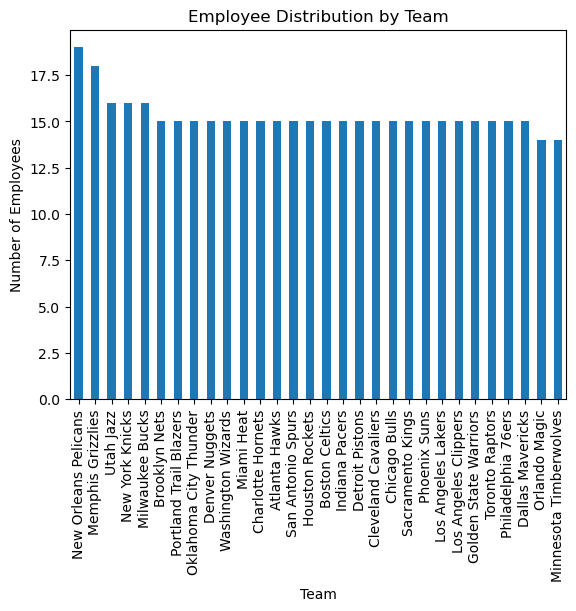

In [99]:
# Team Distribution
team_dist.plot(kind='bar', title='Employee Distribution by Team')
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.show()

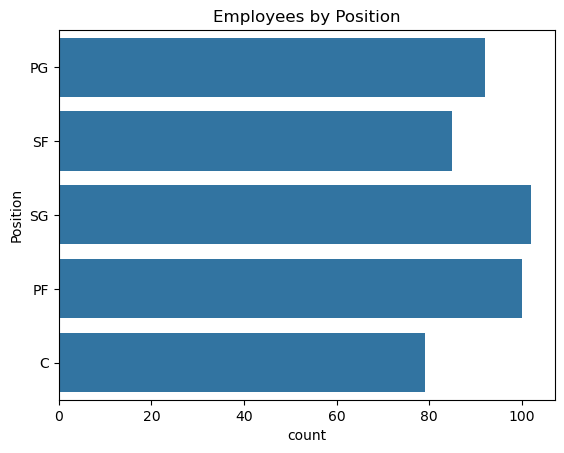

In [100]:
# Position distribution
sns.countplot(y='Position', data=df)
plt.title("Employees by Position")
plt.show()

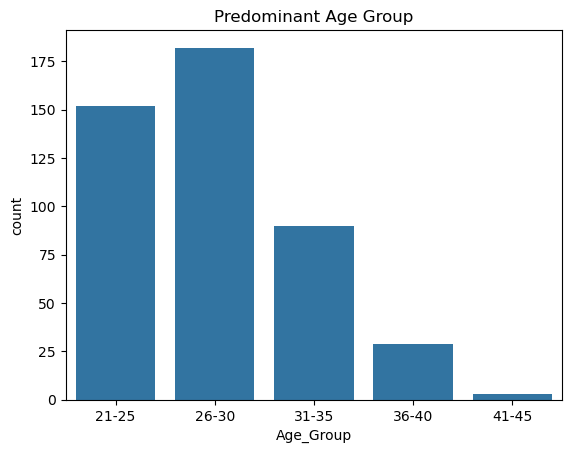

In [101]:
# Age group
sns.countplot(x='Age_Group', data=df, order=age_labels)
plt.title("Predominant Age Group")
plt.show()

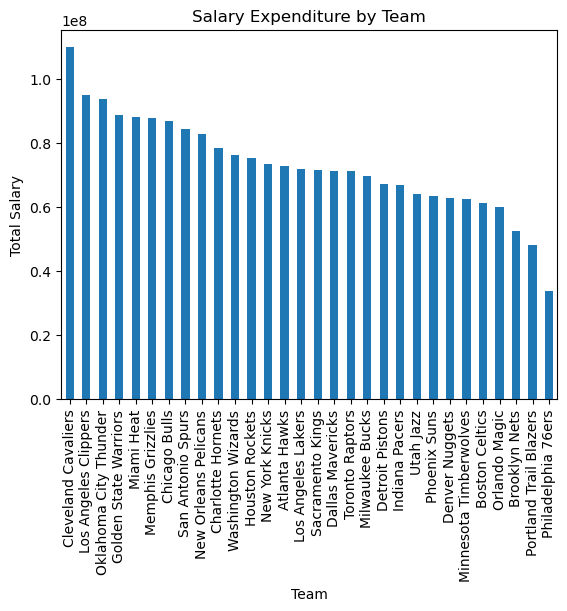

In [102]:
team_salary.plot(kind='bar', title='Salary Expenditure by Team')
plt.ylabel("Total Salary")
plt.show()

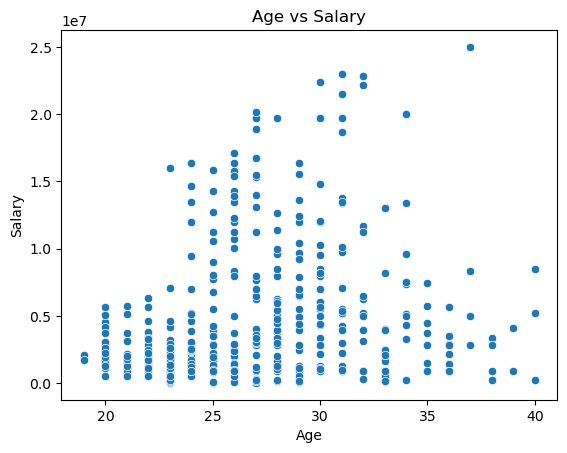

In [103]:
# Correlation: scatter plot
sns.scatterplot(x='Age', y='Salary', data=df)
plt.title("Age vs Salary")
plt.show()

# Data Story

1.According to the dataset in employee distribution by team, Employee distribution is relatively even across teams, with a few teams like New Orleans Pelicans and Memphis Grizzlies employing slightly more staff.
2.Segregation by Position
Most common roles:
SG: 102 employees
PF: 100
PG: 92
3.Predominant Age Group
The majority of employees are in the 26–30 age group.suggesting more young peoples.
4.Salary Allocation: C are the highest-paid, which could be due to their specialized skill sets. Cleveland Cavaliers tops the chart in team payroll.
5.Experience & Pay: There's a weak but noticeable trend that salary increases with age, likely due to experience or tenure.



In [122]:
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,Age_Group
0,Avery Bradley,Boston Celtics,0,PG,25,156,180,Texas,7730337.0,26-30
1,Jae Crowder,Boston Celtics,99,SF,25,169,235,Marquette,6796117.0,26-30
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,2836186.0,26-30
3,R.J. Hunter,Boston Celtics,28,SG,22,164,185,Georgia State,1148640.0,21-25
4,Jonas Jerebko,Boston Celtics,8,PF,29,160,231,Unknown,5000000.0,26-30
...,...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,168,203,Butler,2433333.0,26-30
454,Raul Neto,Utah Jazz,25,PG,24,153,179,Unknown,900000.0,21-25
455,Tibor Pleiss,Utah Jazz,21,C,26,152,256,Unknown,2900000.0,26-30
456,Jeff Withey,Utah Jazz,24,C,26,166,231,Kansas,947276.0,26-30


In [124]:
df.to_csv('ABC_Company_Cleaned.csv', index=False)
